# Missing Value Analysis & Univariate Complete Case Analysis (CCA)
**Dataset:** `data_science_job - data_science_job.csv`

This notebook covers:
1. **Section 1** — Load dataset & inspect structure
2. **Section 2** — Identify Numerical (N) and Categorical (C) variables with missing values > 5%
3. **Section 3** — Apply Univariate CCA (drop rows with missing values in flagged variables)
4. **Section 4** — Plot PDF/Histogram Before vs After CCA for each flagged variable

---
## Section 1 — Import Libraries & Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Inline plots for Jupyter
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

# Load dataset
df = pd.read_csv('data_science_job - data_science_job.csv')
total_rows = len(df)

print("Dataset Shape  :", df.shape)
print("Total Rows     :", total_rows)
print("Total Columns  :", df.shape[1])
df.head()

Dataset Shape  : (19158, 13)
Total Rows     : 19158
Total Columns  : 13


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0


In [2]:
# Data types overview
print("Column Data Types:")
print(df.dtypes)
print("\nTotal missing values per column:")
print(df.isnull().sum())

Column Data Types:
enrollee_id                 int64
city                          str
city_development_index    float64
gender                        str
relevent_experience           str
enrolled_university           str
education_level               str
major_discipline              str
experience                float64
company_size                  str
company_type                  str
training_hours            float64
target                      int64
dtype: object

Total missing values per column:
enrollee_id                  0
city                         0
city_development_index     479
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
training_hours             766
target                       0
dtype: int64


## Section 2 — Identify N/C Variables with Missing Values > 5%

In [3]:
# Separate Numerical and Categorical columns
numerical_cols   = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numerical columns  :", numerical_cols)
print("Categorical columns:", categorical_cols)

Numerical columns  : ['enrollee_id', 'city_development_index', 'experience', 'training_hours', 'target']
Categorical columns: ['city', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'company_size', 'company_type']


In [4]:
def missing_summary(cols, label):
    """Print missing value stats and return list of flagged columns (>5% missing)."""
    print("-" * 60)
    print("  {} Variables -- Missing Value Analysis".format(label))
    print("-" * 60)
    print("{:<30} {:>14} {:>10}".format("Variable", "Missing Count", "Missing %"))
    print("{} {} {}".format("-"*30, "-"*14, "-"*10))

    flagged = []
    for col in cols:
        missing_count = df[col].isna().sum()
        missing_pct   = (missing_count / total_rows) * 100
        marker = "  *** > 5%" if missing_pct > 5 else ""
        print("{:<30} {:>14,} {:>9.2f}%{}".format(col, missing_count, missing_pct, marker))
        if missing_pct > 5:
            flagged.append((col, missing_count, missing_pct))

    print("\n  -> Variables with missing > 5%: {}".format(len(flagged)))
    for col, cnt, pct in flagged:
        print("     * {}  ({:,} missing | {:.2f}%)".format(col, cnt, pct))
    return flagged

# Run analysis
print("=" * 60)
num_flagged = missing_summary(numerical_cols,   "Numerical (N)")
print()
cat_flagged = missing_summary(categorical_cols, "Categorical (C)")

------------------------------------------------------------
  Numerical (N) Variables -- Missing Value Analysis
------------------------------------------------------------
Variable                        Missing Count  Missing %
------------------------------ -------------- ----------
enrollee_id                                 0      0.00%
city_development_index                    479      2.50%
experience                                 65      0.34%
training_hours                            766      4.00%
target                                      0      0.00%

  -> Variables with missing > 5%: 0

------------------------------------------------------------
  Categorical (C) Variables -- Missing Value Analysis
------------------------------------------------------------
Variable                        Missing Count  Missing %
------------------------------ -------------- ----------
city                                        0      0.00%
gender                                  4,

In [5]:
# Combined final summary
all_flagged = [("Numerical",   *x) for x in num_flagged] + \
              [("Categorical", *x) for x in cat_flagged]

print("=" * 60)
print("  FINAL SUMMARY -- Variables with Missing Values > 5%")
print("=" * 60)

if all_flagged:
    print("\n{:<14} {:<30} {:>8} {:>8}".format("Type", "Variable", "Missing", "%"))
    print("{} {} {} {}".format("-"*14, "-"*30, "-"*8, "-"*8))
    for vtype, col, cnt, pct in all_flagged:
        print("{:<14} {:<30} {:>8,} {:>7.2f}%".format(vtype, col, cnt, pct))
else:
    print("  [OK] No variables have more than 5% missing values.")

print("\n" + "=" * 60)

# Collect only categorical flagged variable names for CCA
flagged_vars = [col for col, cnt, pct in cat_flagged]
print("\nFlagged categorical variables for CCA:", flagged_vars)

  FINAL SUMMARY -- Variables with Missing Values > 5%

Type           Variable                        Missing        %
-------------- ------------------------------ -------- --------
Categorical    gender                            4,508   23.53%
Categorical    major_discipline                  2,813   14.68%
Categorical    company_size                      5,938   30.99%
Categorical    company_type                      6,140   32.05%


Flagged categorical variables for CCA: ['gender', 'major_discipline', 'company_size', 'company_type']


## Section 3 — Apply Univariate CCA
**Complete Case Analysis (CCA):** Drop all rows where any of the flagged categorical variables has a missing value.

In [6]:
# Apply CCA — drop rows with NaN in any of the flagged variables
df_cca = df.dropna(subset=flagged_vars).copy()
dropped = total_rows - len(df_cca)

print("=" * 50)
print("  Univariate CCA Summary")
print("=" * 50)
print("Rows BEFORE CCA : {:,}".format(total_rows))
print("Rows AFTER  CCA : {:,}".format(len(df_cca)))
print("Rows DROPPED    : {:,}  ({:.2f}%)".format(dropped, dropped / total_rows * 100))
print("=" * 50)

  Univariate CCA Summary
Rows BEFORE CCA : 19,158
Rows AFTER  CCA : 9,046
Rows DROPPED    : 10,112  (52.78%)


In [7]:
# Per-variable distribution comparison table (Before vs After CCA)
for col in flagged_vars:
    before  = df[col].value_counts(normalize=True).mul(100).round(2)
    after   = df_cca[col].value_counts(normalize=True).mul(100).round(2)
    summary = pd.DataFrame({'Before CCA (%)': before, 'After CCA (%)': after})
    summary['Diff (%)'] = (summary['After CCA (%)'] - summary['Before CCA (%)']).round(2)
    print("\nVariable: {}".format(col))
    print(summary.to_string())
    print()


Variable: gender
        Before CCA (%)  After CCA (%)  Diff (%)
gender                                         
Male             90.25          90.14     -0.11
Female            8.45           8.97      0.52
Other             1.30           0.90     -0.40


Variable: major_discipline
                  Before CCA (%)  After CCA (%)  Diff (%)
major_discipline                                         
STEM                       88.66          89.24      0.58
Humanities                  4.09           4.19      0.10
Other                       2.33           1.99     -0.34
Business Degree             2.00           1.89     -0.11
Arts                        1.55           1.43     -0.12
No Major                    1.36           1.26     -0.10


Variable: company_size
              Before CCA (%)  After CCA (%)  Diff (%)
company_size                                         
50-99                  23.32          22.24     -1.08
100-500                19.45          20.21      0.76
10000+  

## Section 4 — PDF / Histogram: Before vs After CCA
Normalized bar charts (relative frequency ≈ PDF) for each flagged categorical variable.

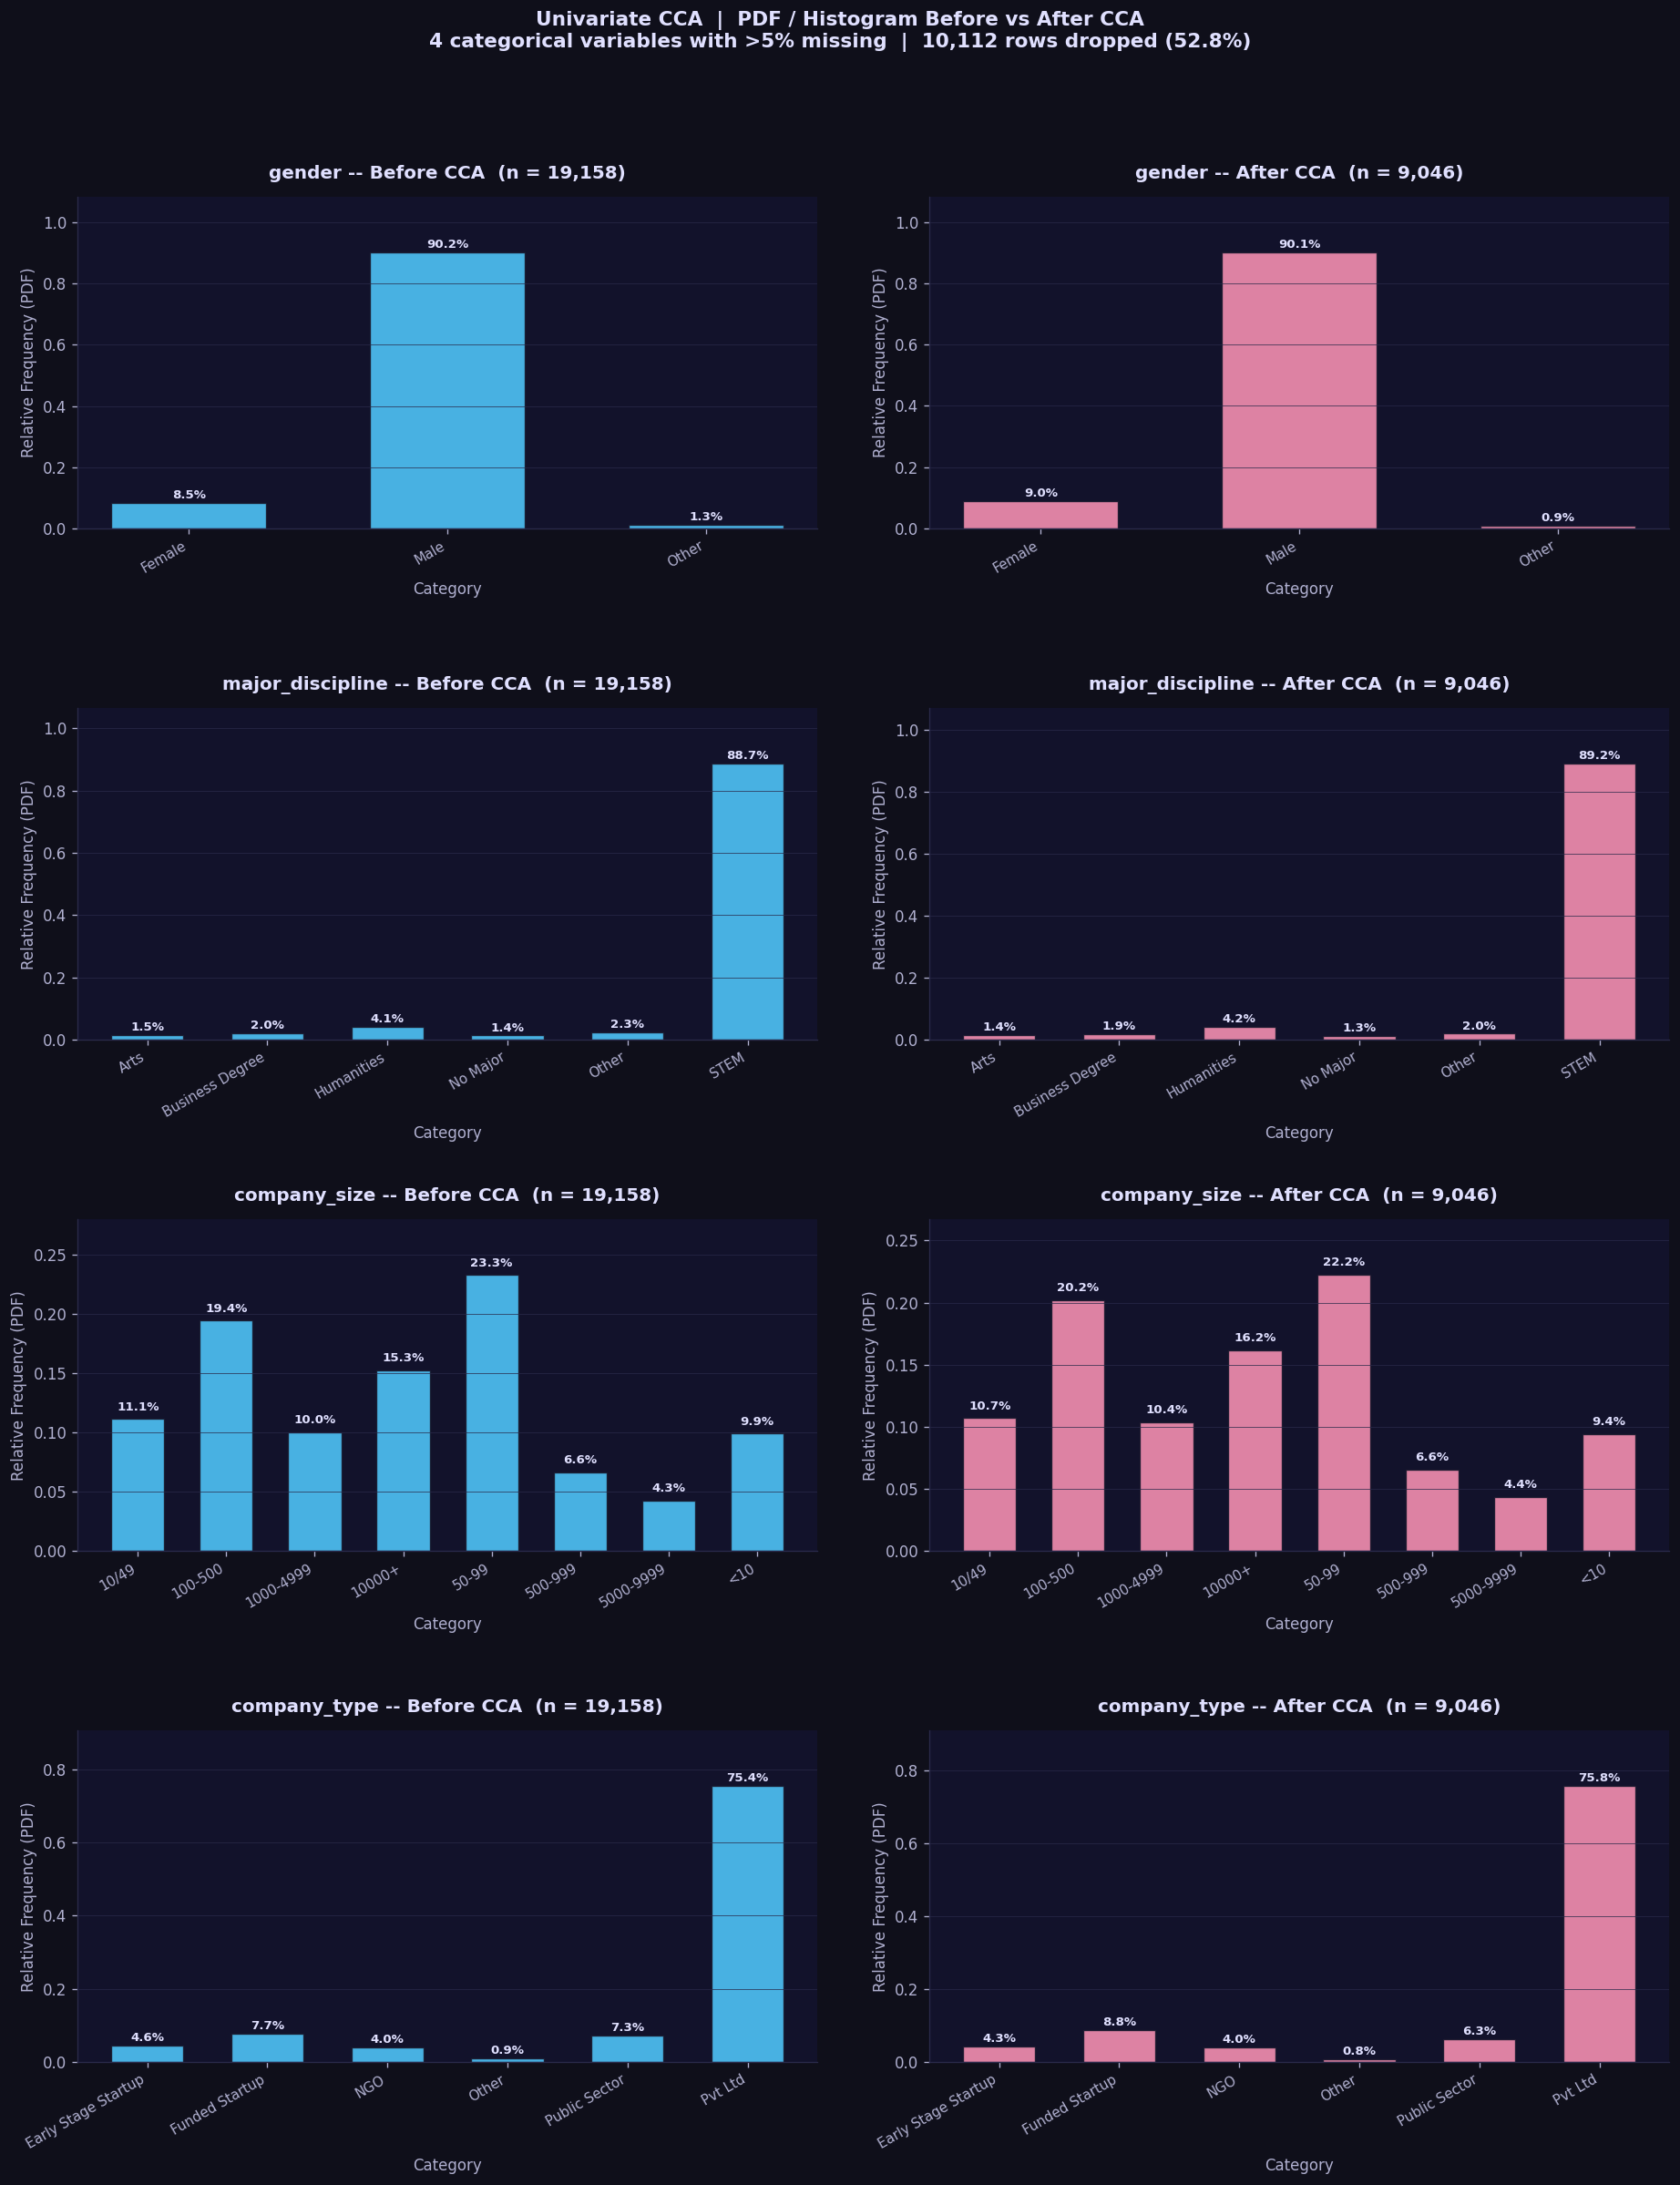

Plot saved as 'univariate_cca_plots.png'


In [8]:
# ── Color scheme ─────────────────────────────────────────────
BEFORE_COLOR = '#4fc3f7'
AFTER_COLOR  = '#f48fb1'
EDGE_COLOR   = '#1a1a2e'
TITLE_COLOR  = '#e0e0ff'
LABEL_COLOR  = '#b0b0d0'
GRID_COLOR   = '#2a2a4a'
BG_DARK      = '#0f0f1a'
AX_BG        = '#12122b'

n_vars = len(flagged_vars)
fig, axes = plt.subplots(n_vars, 2, figsize=(16, 5 * n_vars))
fig.patch.set_facecolor(BG_DARK)

for i, col in enumerate(flagged_vars):
    ax_before = axes[i][0]
    ax_after  = axes[i][1]

    # Normalized value counts
    before_counts = df[col].value_counts(normalize=True).sort_index()
    after_counts  = df_cca[col].value_counts(normalize=True).sort_index()

    all_cats    = sorted(set(before_counts.index) | set(after_counts.index))
    before_vals = [before_counts.get(c, 0) for c in all_cats]
    after_vals  = [after_counts.get(c,  0) for c in all_cats]

    x         = range(len(all_cats))
    bar_width = 0.6

    for ax, vals, color, stage, n in [
        (ax_before, before_vals, BEFORE_COLOR, "Before CCA", total_rows),
        (ax_after,  after_vals,  AFTER_COLOR,  "After CCA",  len(df_cca)),
    ]:
        ax.set_facecolor(AX_BG)
        bars = ax.bar(x, vals, width=bar_width, color=color,
                      edgecolor=EDGE_COLOR, linewidth=0.8, alpha=0.90)

        # Annotate bars
        for bar, v in zip(bars, vals):
            if v > 0.005:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.005,
                        "{:.1f}%".format(v * 100),
                        ha='center', va='bottom',
                        fontsize=8, color=TITLE_COLOR, fontweight='bold')

        ax.set_xticks(list(x))
        ax.set_xticklabels(all_cats, rotation=30, ha='right',
                           fontsize=9, color=LABEL_COLOR)
        ax.set_ylabel("Relative Frequency (PDF)", color=LABEL_COLOR, fontsize=10)
        ax.set_xlabel("Category", color=LABEL_COLOR, fontsize=10)
        ax.tick_params(colors=LABEL_COLOR)
        ax.set_title("{} -- {}  (n = {:,})".format(col, stage, n),
                     color=TITLE_COLOR, fontsize=12, fontweight='bold', pad=12)
        ax.spines['bottom'].set_color(GRID_COLOR)
        ax.spines['left'].set_color(GRID_COLOR)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.yaxis.set_tick_params(labelcolor=LABEL_COLOR)
        ax.xaxis.set_tick_params(labelcolor=LABEL_COLOR)
        ax.grid(axis='y', color=GRID_COLOR, linewidth=0.6, alpha=0.7)
        ax.set_ylim(0, max(vals) * 1.20 if max(vals) > 0 else 1)

fig.suptitle(
    "Univariate CCA  |  PDF / Histogram Before vs After CCA\n"
    "{} categorical variables with >5% missing  |  {:,} rows dropped ({:.1f}%)".format(
        n_vars, dropped, dropped / total_rows * 100),
    color=TITLE_COLOR, fontsize=13, fontweight='bold', y=1.01
)

plt.tight_layout(pad=3.0)
plt.savefig('univariate_cca_plots.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("Plot saved as 'univariate_cca_plots.png'")

---
## Summary

| Step | Result |
|---|---|
| Dataset shape | (19158, 13) |
| Numerical variables with >5% missing | **None** |
| Categorical variables with >5% missing | `gender`, `major_discipline`, `company_size`, `company_type` |
| Rows before CCA | 19,158 |
| Rows after CCA | 9,046 |
| Rows dropped | 10,112 (52.78%) |

> **Observation:** The distributions of all 4 variables remain nearly identical before and after CCA, suggesting the missing data is approximately **MCAR (Missing Completely At Random)**.